# Friendship Paradox Analysis on Real-world and Random Networks

In [19]:
import warnings
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.linalg import expm
from scipy.stats import norm
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_networkx

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

## I. Datasets

In [20]:
graphs = {}
graphs['Karate Club'] = nx.karate_club_graph()
graphs["Dolphins"] = nx.generators.social.florentine_families_graph()
graphs["Les Miserables"] = nx.generators.social.les_miserables_graph()

# 1. Cora
try:
  dataset_cora = Planetoid(root='./data', name='Cora')
  cora = to_networkx(dataset_cora[0], to_undirected=True)
  graphs['Cora'] = cora
except Exception as e:
  print(f'Erreur chargement Cora: {e}')

# 2. CiteSeer
try:
  dataset_citeseer = Planetoid(root='./data', name='CiteSeer')
  citeseer = to_networkx(dataset_citeseer[0], to_undirected=True)
  graphs['CiteSeer'] = citeseer
except Exception as e:
  print(f'Erreur chargement CiteSeer: {e}')

## II. Centralities

In [21]:
def degree_centrality(G):
  return nx.degree_centrality(G)


def eigenvector_centrality(G):
  try:
    return nx.eigenvector_centrality(G, max_iter=2000, tol=1e-6)
  except Exception:
    return {n: np.nan for n in G.nodes()}


def katz_centrality(G):
  try:
    A = nx.to_numpy_array(G)
    eigvals = np.linalg.eigvals(A).real
    lambda_max = max(eigvals) if len(eigvals) > 0 else 0
    alpha = 0.85 / lambda_max if lambda_max > 0 else 0.1
    I = np.eye(len(G))
    x = np.linalg.solve(I - alpha * A, np.ones(len(G)))
    return dict(zip(G.nodes(), x))
  except Exception:
    return {n: np.nan for n in G.nodes()}


def walk_centrality(G, l=2):
  A = nx.to_numpy_array(G)
  x = np.linalg.matrix_power(A, l) @ np.ones(len(G))
  return dict(zip(G.nodes(), x))


def exponential_centrality(G, alpha=0.01):
  A = nx.to_numpy_array(G)
  E = expm(alpha * A)
  x = E @ np.ones(len(G))
  return dict(zip(G.nodes(), x))


def nonbacktracking_centrality(G):
  n = len(G)
  try:
    A = nx.to_numpy_array(G)
    D = np.diag([G.degree(v) for v in G.nodes()])
    I = np.eye(n)
    B = np.block([[A, I - D], [I, np.zeros((n, n))]])

    eigvals, eigvecs = np.linalg.eig(B)
    idx = np.argmax(eigvals.real)
    x = eigvecs[:n, idx].real
    norm_x = np.linalg.norm(x)
    if norm_x > 0:
      x /= norm_x
    return dict(zip(G.nodes(), x))
  except Exception:
    return {n: np.nan for n in G.nodes()}


centralities = {
    'Degree': degree_centrality,
    'Eigenvector': eigenvector_centrality,
    'Walk': walk_centrality,
    'Katz': katz_centrality,
    'Exponential': exponential_centrality,
    'Non-backtracking': nonbacktracking_centrality,
}

### Computation functions

In [22]:
def delta_values(G, centrality_function):
  x = centrality_function(G)
  delta = {}
  local_importance = {}

  for node in G.nodes():
    neighbors = list(G.neighbors(node))
    if len(neighbors) == 0 or np.isnan(x[node]):
      delta[node] = np.nan
      local_importance[node] = np.nan
      continue

    valid_neigh_x = [x[v] for v in neighbors if not np.isnan(x[v])]
    if len(valid_neigh_x) == 0:
      delta[node] = np.nan
      local_importance[node] = np.nan
      continue

    mean_neighbors = np.mean(valid_neigh_x)
    d_i = mean_neighbors - x[node]
    delta[node] = d_i
    local_importance[node] = np.exp(-d_i)  # Devoir IV : exp(-Delta_i)

  return delta, local_importance, x


def friendship_paradox_statistics(delta):
  valid = [d for d in delta.values() if not np.isnan(d)]
  if len(valid) == 0:
    return 0, 0, np.nan, np.nan
  count = sum(d >= 0 for d in valid)
  total = len(valid)
  percentage = 100 * count / total
  expected_delta = np.mean(valid)
  return count, total, percentage, expected_delta


def random_graph_like(G, factor=1.0):
  n = G.number_of_nodes()
  m = G.number_of_edges()
  if n <= 1:
    return nx.erdos_renyi_graph(n, 0, seed=42)
  p = factor * (2 * m) / (n * (n - 1))
  return nx.erdos_renyi_graph(n, p, seed=42)

## III. Experiments

## 1. Global Friendship Paradox

In [25]:
gfp_results = []

for graph_name, G in graphs.items():
  G_random = random_graph_like(G, factor=1.0)


  d_real = np.array([G.degree(n) for n in G.nodes()])
  d_rand = np.array([G_random.degree(n) for n in G_random.nodes()])

  for name, func in centralities.items():
    _, _, x_real_dict = delta_values(G, func)
    _, _, x_rand_dict = delta_values(G_random, func)

    x_real = np.array([x_real_dict[n] for n in G.nodes()])
    x_rand = np.array([x_rand_dict[n] for n in G_random.nodes()])


    avg_node_real = np.mean(x_real)  # (1^T x) / n
    avg_neighbor_real = (
        np.dot(d_real, x_real) / np.sum(d_real)
        if np.sum(d_real) > 0
        else np.nan
    )  # (d^T x) / (1^T d)
    delta_gfp_real = avg_neighbor_real - avg_node_real
    gfp_real_holds = delta_gfp_real >= 0


    avg_node_rand = np.mean(x_rand)
    avg_neighbor_rand = (
        np.dot(d_rand, x_rand) / np.sum(d_rand)
        if np.sum(d_rand) > 0
        else np.nan
    )
    delta_gfp_rand = avg_neighbor_rand - avg_node_rand
    gfp_rand_holds = delta_gfp_rand >= 0


    gfp_results.append({
        "Graph": graph_name,
        "Centrality": name,
        "Real E[x_nodes]": avg_node_real,
        "Real E[x_neighbors]": avg_neighbor_real,
        "Real Delta_GFP": delta_gfp_real,
        "Real GFP Holds": gfp_real_holds,
        "Random E[x_nodes]": avg_node_rand,
        "Random E[x_neighbors]": avg_neighbor_rand,
        "Random Delta_GFP": delta_gfp_rand,
        "Random GFP Holds": gfp_rand_holds,
    })


df_gfp = pd.DataFrame(gfp_results)
df_gfp.to_excel("outputs/gfp_results.xlsx", index=False)

print(
    df_gfp[
        [
            "Graph",
            "Centrality",
            "Real Delta_GFP",
            "Real GFP Holds",
            "Random Delta_GFP",
            "Random GFP Holds",
        ]
    ]
)

             Graph        Centrality  Real Delta_GFP  Real GFP Holds  \
0      Karate Club            Degree        0.096394            True   
1      Karate Club       Eigenvector        0.068207            True   
2      Karate Club              Walk      140.535445            True   
3      Karate Club              Katz        2.031014            True   
4      Karate Club       Exponential        0.102516            True   
5      Karate Club  Non-backtracking        0.074244            True   
6         Dolphins            Degree        0.048810            True   
7         Dolphins       Eigenvector        0.051614            True   
8         Dolphins              Walk        1.566667            True   
9         Dolphins              Katz        1.031402            True   
10        Dolphins       Exponential        0.006913            True   
11        Dolphins  Non-backtracking        0.036260            True   
12  Les Miserables            Degree        0.071812            

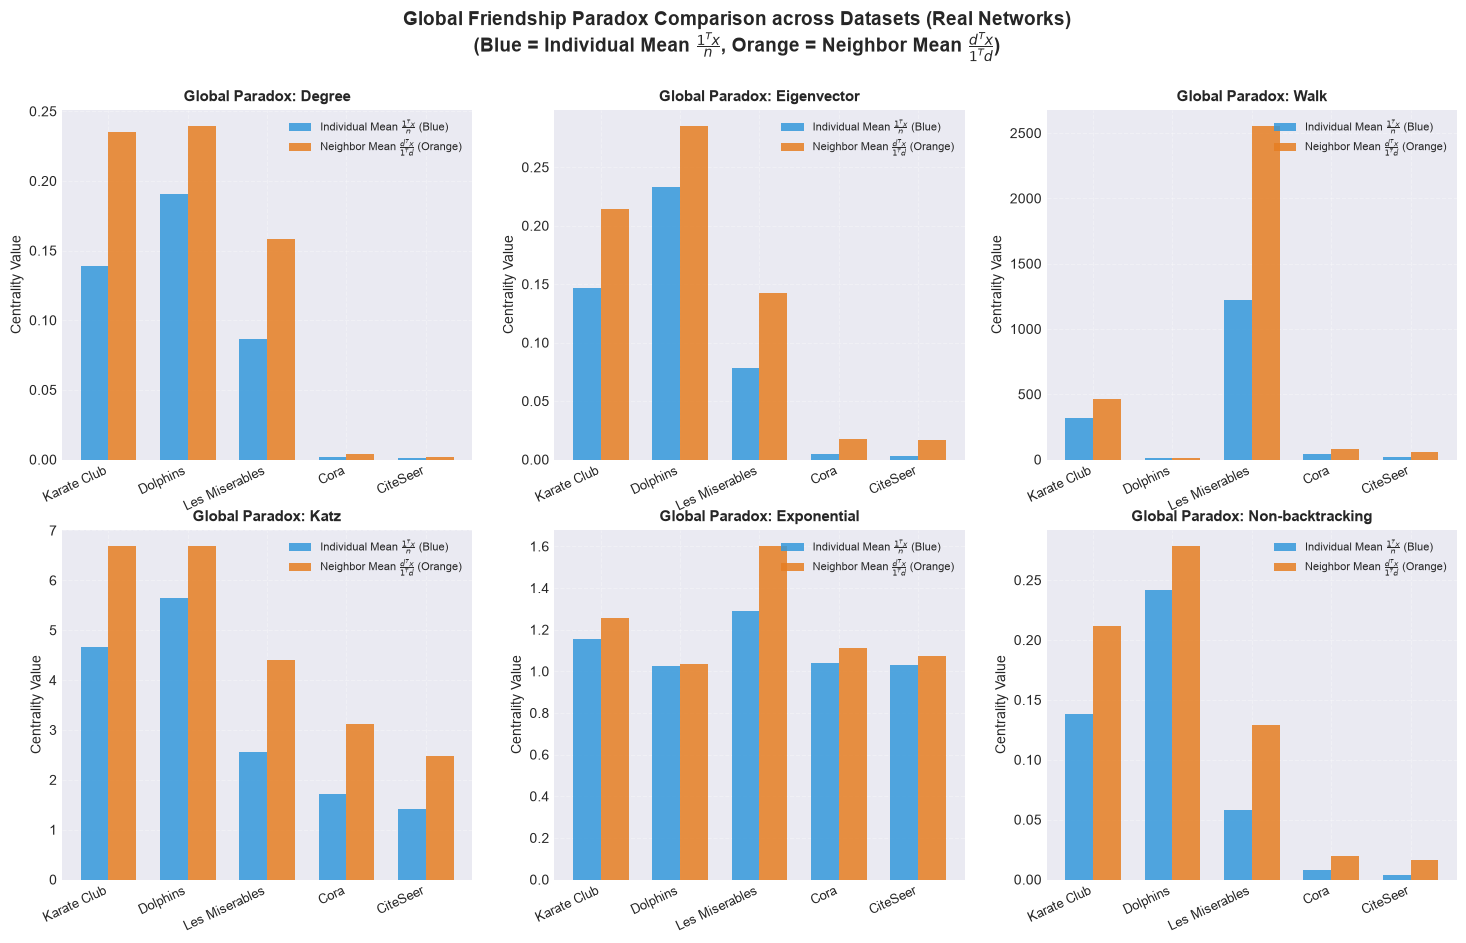

<Figure size 640x480 with 0 Axes>

In [26]:
df_plot = df_gfp.copy()

list_centralities = df_plot["Centrality"].unique()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, c_target in enumerate(list_centralities):

  df_sub = df_plot[df_plot["Centrality"] == c_target]

  if not df_sub.empty and idx < len(axes):

    x = np.arange(len(df_sub["Graph"]))
    width = 0.35

    axes[idx].bar(
        x - width / 2,
        df_sub["Real E[x_nodes]"],
        width,
        label=r"Individual Mean $\frac{1^T x}{n}$ (Blue)",
        color="#3498db",
        alpha=0.85,
    )

    axes[idx].bar(
        x + width / 2,
        df_sub["Real E[x_neighbors]"],
        width,
        label=r"Neighbor Mean $\frac{d^T x}{1^T d}$ (Orange)",
        color="#e67e22",
        alpha=0.85,
    )

    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(
        df_sub["Graph"], rotation=25, ha="right", fontsize=9
    )
    axes[idx].set_title(
        f"Global Paradox: {c_target}", fontweight="bold", fontsize=11
    )
    axes[idx].set_ylabel("Centrality Value")
    axes[idx].legend(loc="upper right", fontsize=8)
    axes[idx].grid(True, linestyle="--", alpha=0.3)
  else:
    axes[idx].set_visible(False)

for j in range(len(list_centralities), len(axes)):
  axes[j].set_visible(False)

plt.suptitle(
    "Global Friendship Paradox Comparison across Datasets (Real Networks)\n"
    r"(Blue = Individual Mean $\frac{1^T x}{n}$, Orange = Neighbor Mean"
    r" $\frac{d^T x}{1^T d}$)",
    fontsize=14,
    fontweight="bold",
)
plt.show()
plt.tight_layout()
plt.savefig("figs/global_paradox_comparison.pdf", bbox_inches="tight")
plt.close(fig)

## 2. Local Friendship Paradox

In [27]:
results_summary = []
node_level_details = []

for graph_name, G in graphs.items():
  print('=' * 70)
  print(f'Processing Graph: {graph_name}')
  print('=' * 70)

  G_random = random_graph_like(G, factor=1.0)

  # Empirical variance of degree
  deg_var_real = np.var([d for _, d in G.degree()])
  deg_var_rand = np.var([d for _, d in G_random.degree()])

  print(
      f'Degree Variance -> Real: {deg_var_real:.2f} | Random:'
      f' {deg_var_rand:.2f}'
  )

  for name, func in centralities.items():
    # Real Graph
    delta_real, imp_real, x_real = delta_values(G, func)
    c_real, t_real, p_real, e_real = friendship_paradox_statistics(delta_real)

    # Random Graph
    delta_rand, imp_rand, x_rand = delta_values(G_random, func)
    c_rand, t_rand, p_rand, e_rand = friendship_paradox_statistics(delta_rand)

    # Correlation between exp(-Delta_i) and x_i
    vec_imp = np.array(
        [imp_real[n] for n in G.nodes() if not np.isnan(imp_real[n])]
    )
    vec_x = np.array([x_real[n] for n in G.nodes() if not np.isnan(imp_real[n])])
    corr_imp = (
        np.corrcoef(vec_imp, vec_x)[0, 1] if len(vec_x) > 1 else np.nan
    )

    results_summary.append({
        'Graph': graph_name,
        'Centrality': name,
        'Real % ∆i>=0': p_real,
        'Random % ∆i>=0': p_rand,
        'Real E[∆i]': e_real,
        'Random E[∆i]': e_rand,
        'Real Deg Var': deg_var_real,
        'Random Deg Var': deg_var_rand,
        'Corr(exp(-∆i), x)': corr_imp,
    })

    print(
        f'\n{name:<18} | Real: {c_real}/{t_real} ({p_real:.2f}%) E[∆]={e_real:.4f}'
    )
    print(
        f"{'':<18} | Rand: {c_rand}/{t_rand} ({p_rand:.2f}%) E[∆]={e_rand:.4f}"
    )

    for n in G.nodes():
      if not np.isnan(delta_real[n]):
        node_level_details.append({
            'Graph': graph_name,
            'Centrality': name,
            'Type': 'Real',
            'Node': n,
            'x_i': x_real[n],
            'Delta_i': delta_real[n],
            'exp(-Delta_i)': imp_real[n],
        })
    for n in G_random.nodes():
      if not np.isnan(delta_rand[n]):
        node_level_details.append({
            'Graph': graph_name,
            'Centrality': name,
            'Type': 'Random (ER)',
            'Node': n,
            'x_i': x_rand[n],
            'Delta_i': delta_rand[n],
            'exp(-Delta_i)': imp_rand[n],
        })

df_summary = pd.DataFrame(results_summary)
df_details = pd.DataFrame(node_level_details)

Processing Graph: Karate Club
Degree Variance -> Real: 14.60 | Random: 2.83

Degree             | Real: 29/34 (85.29%) E[∆]=0.1522
                   | Rand: 22/34 (64.71%) E[∆]=0.0164

Eigenvector        | Real: 29/34 (85.29%) E[∆]=0.0982
                   | Rand: 22/34 (64.71%) E[∆]=0.0186

Walk               | Real: 27/34 (79.41%) E[∆]=194.9809
                   | Rand: 22/34 (64.71%) E[∆]=2.6951

Katz               | Real: 29/34 (85.29%) E[∆]=2.9337
                   | Rand: 22/34 (64.71%) E[∆]=0.5462

Exponential        | Real: 29/34 (85.29%) E[∆]=0.1581
                   | Rand: 22/34 (64.71%) E[∆]=0.0055

Non-backtracking   | Real: 29/34 (85.29%) E[∆]=0.1050
                   | Rand: 12/34 (35.29%) E[∆]=-0.0155
Processing Graph: Dolphins
Degree Variance -> Real: 1.82 | Random: 1.85

Degree             | Real: 12/15 (80.00%) E[∆]=0.0627
                   | Rand: 9/14 (64.29%) E[∆]=0.0534

Eigenvector        | Real: 12/15 (80.00%) E[∆]=0.0549
                   | Rand: 10/14

In [28]:
df_summary.to_excel("outputs/df_summary.xlsx", index=False)
df_details.to_excel("outputs/df_details.xlsx", index=False)
df_summary

,Graph,Centrality,Real % ∆i>=0,Random % ∆i>=0,Real E[∆i],Random E[∆i],Real Deg Var,Random Deg Var,"Corr(exp(-∆i), x)"
0,Karate Club,Degree,85.294118,64.705882,0.152181,0.016372,14.595156,2.826990,0.936319
1,Karate Club,Eigenvector,85.294118,64.705882,0.098190,0.018631,14.595156,2.826990,0.806873
2,Karate Club,Walk,79.411765,64.705882,194.980909,2.695063,14.595156,2.826990,0.313186
3,Karate Club,Katz,85.294118,64.705882,2.933681,0.546243,14.595156,2.826990,0.557211
4,Karate Club,Exponential,85.294118,64.705882,0.158103,0.005540,14.595156,2.826990,0.940532
5,Karate Club,Non-backtracking,85.294118,35.294118,0.104984,-0.015547,14.595156,2.826990,0.844271
6,Dolphins,Degree,80.000000,64.285714,0.062698,0.053401,1.822222,1.848889,0.903441
7,Dolphins,Eigenvector,80.000000,71.428571,0.054938,0.053076,1.822222,1.848889,0.832644
8,Dolphins,Walk,60.000000,57.142857,1.588889,1.558333,1.822222,1.848889,0.425032
9,Dolphins,Katz,80.000000,71.428571,1.143266,1.056831,1.822222,1.848889,0.549053


## IV. Plots

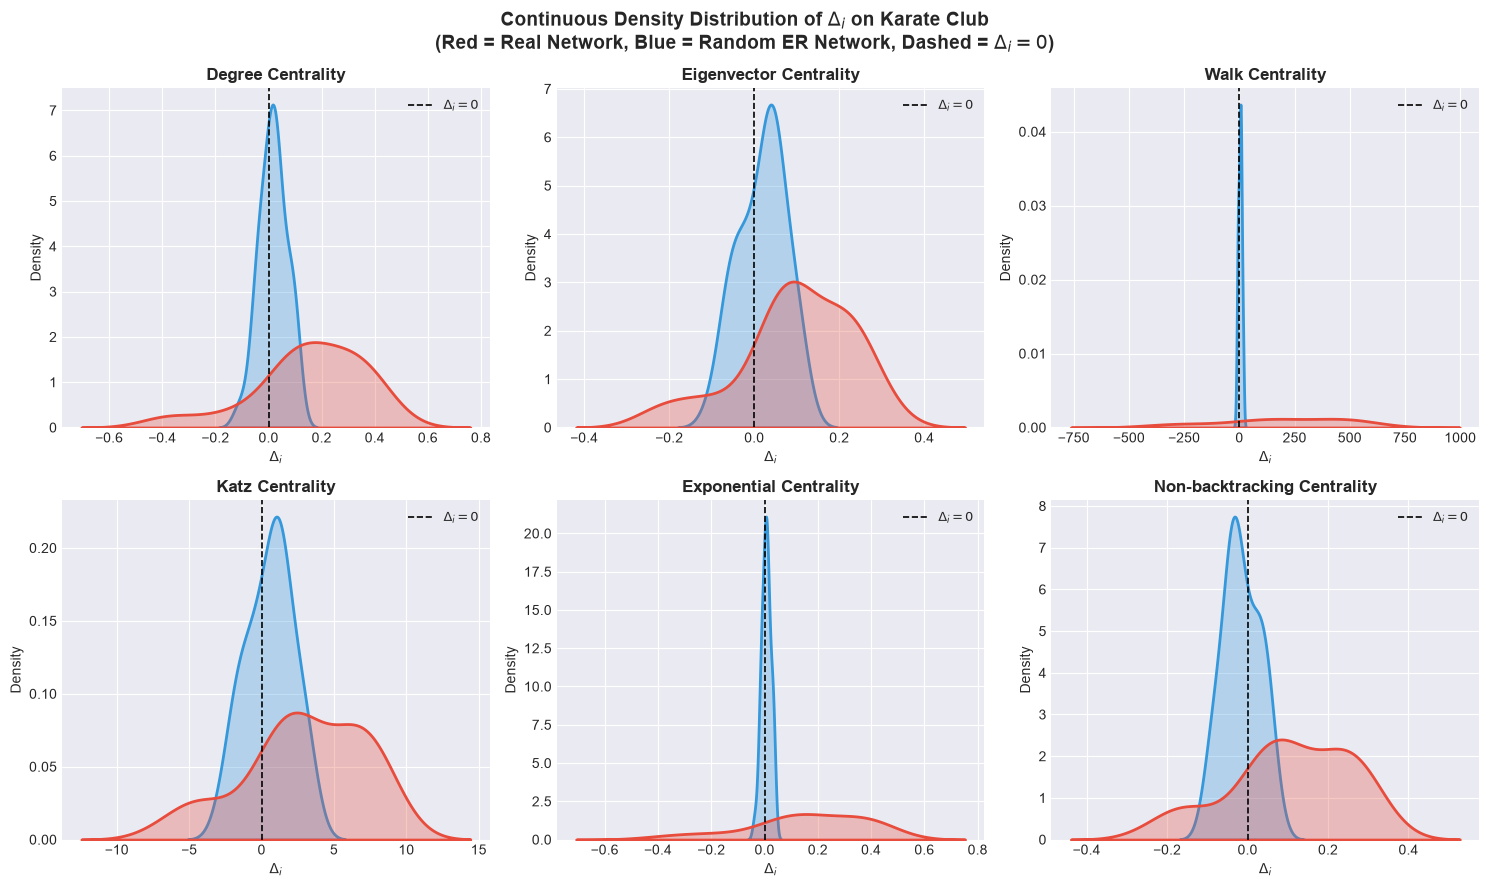

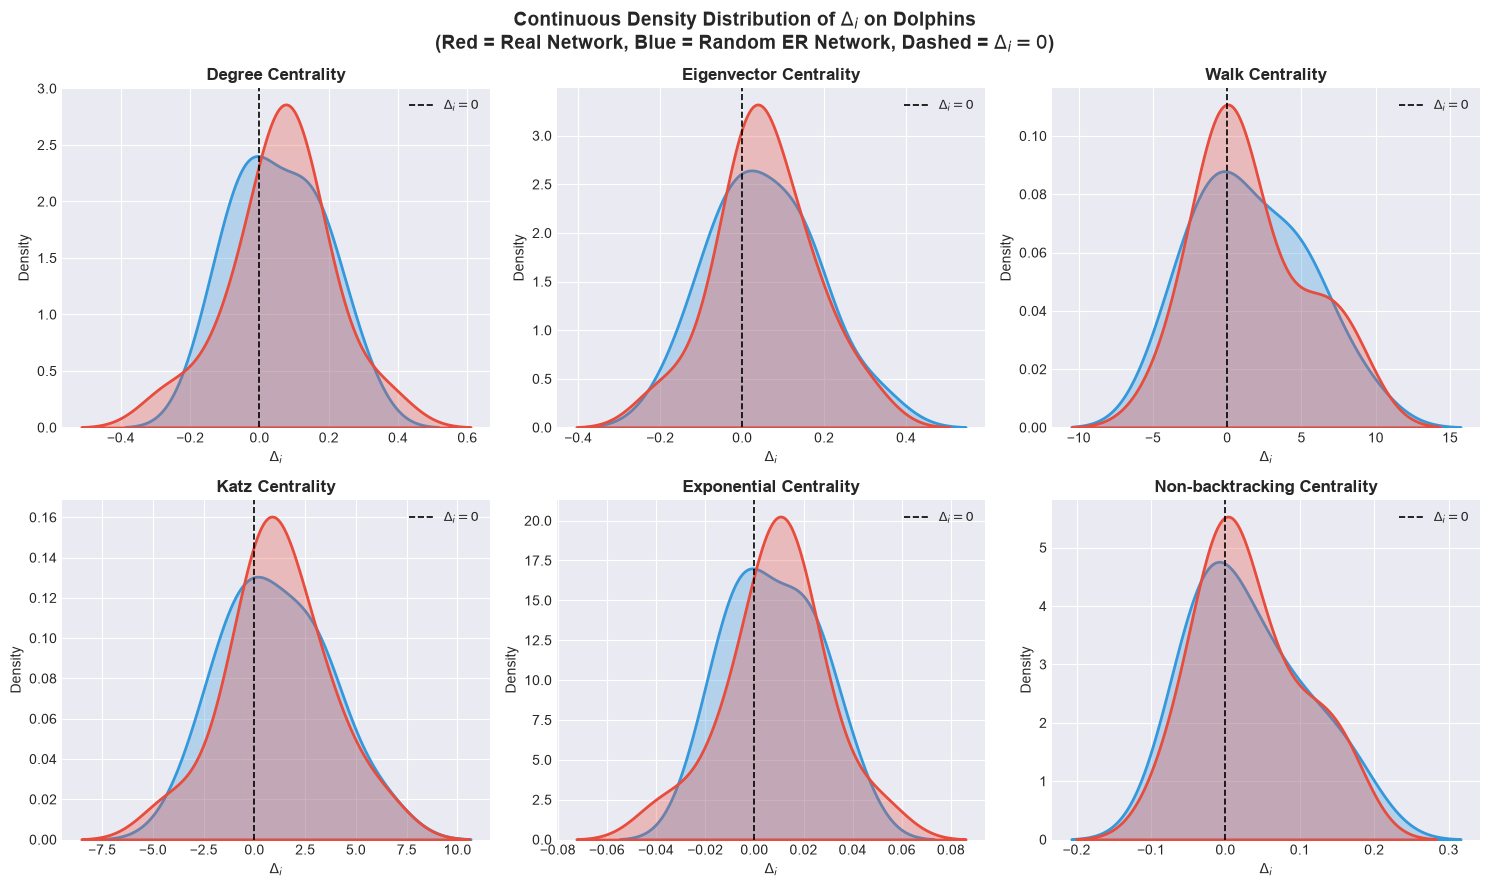

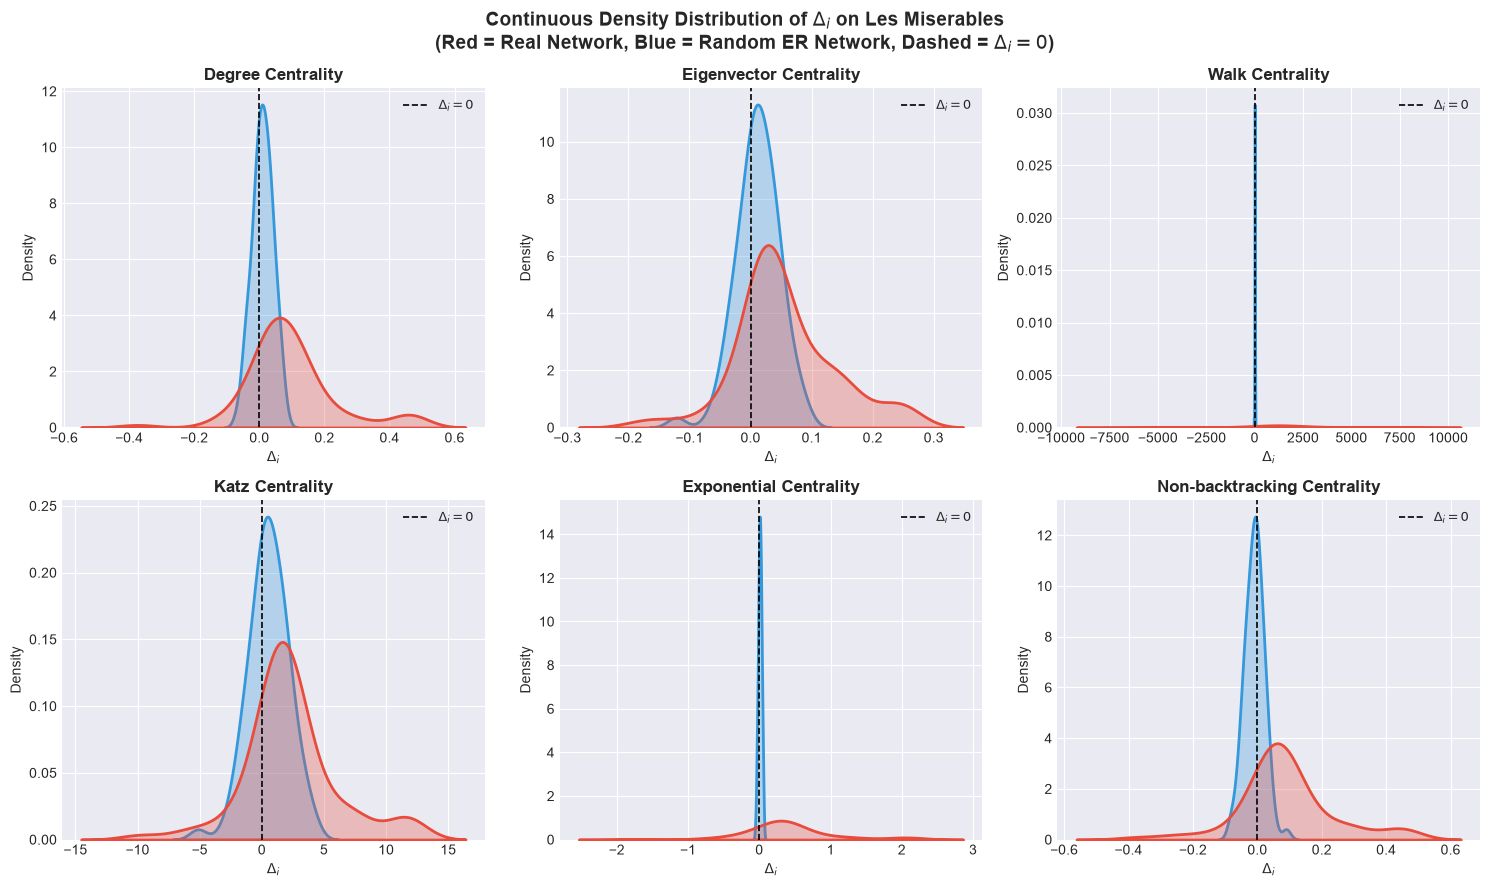

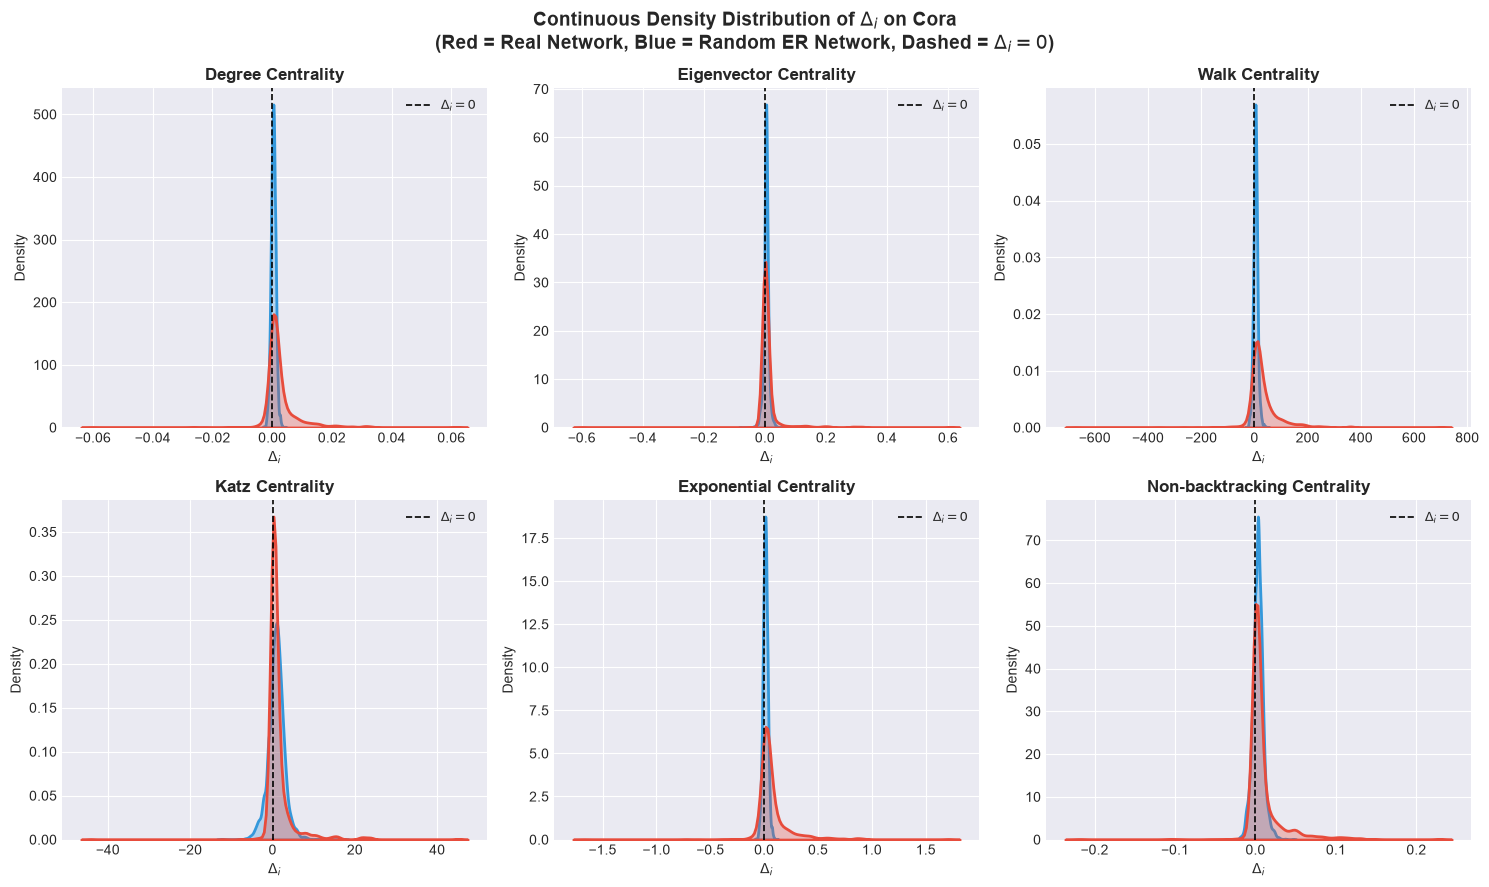

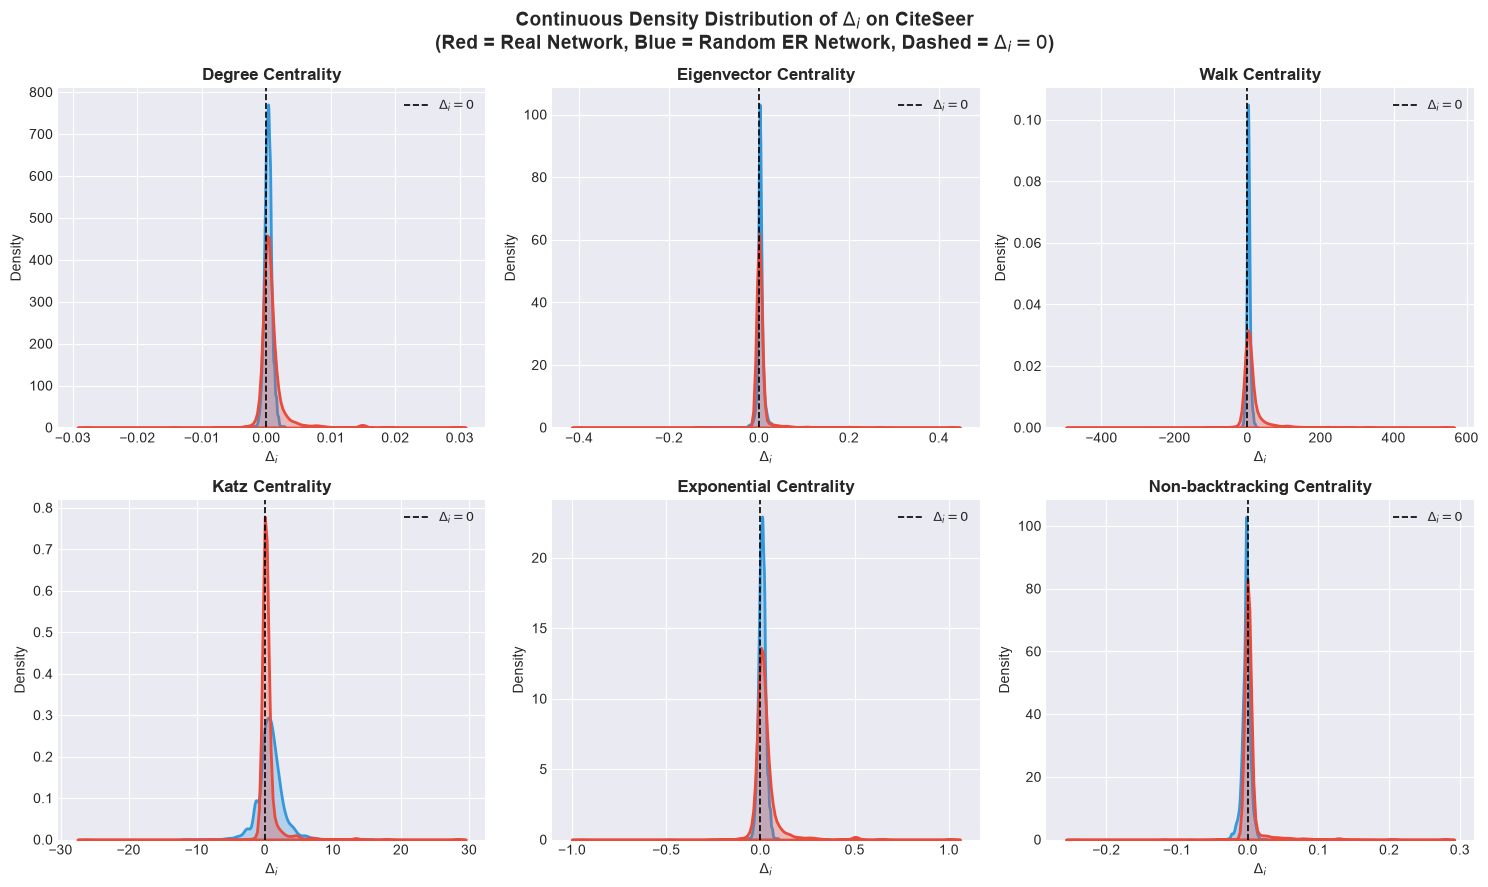

In [29]:
# PLOT 1: Continuous Density Distributions of Delta_i (Real vs Random)
color_palette = {"Real": "#e74c3c", "Random (ER)": "#3498db"}
for target_graph in df_details["Graph"].unique():

  df_sub = df_details[df_details["Graph"] == target_graph]

  fig, axes = plt.subplots(2, 3, figsize=(15, 9))
  axes = axes.flatten()

  for idx, (c_name, _) in enumerate(centralities.items()):
    ax = axes[idx]
    sub_data = df_sub[df_sub["Centrality"] == c_name]
    sns.kdeplot(
        data=sub_data,
        x="Delta_i",
        hue="Type",
        common_norm=False,
        fill=True,
        alpha=0.3,
        linewidth=2,
        ax=ax,
        palette=color_palette,
    )

    ax.axvline(
        0, color="black", linestyle="--", linewidth=1.2, label=r"$\Delta_i = 0$"
    )

    ax.set_title(f"{c_name} Centrality", fontweight="bold")
    ax.set_xlabel(r"$\Delta_i$")
    ax.set_ylabel("Density")

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=labels, loc="upper right", fontsize=9)

  plt.suptitle(
      f"Continuous Density Distribution of $\Delta_i$ on {target_graph}\n"
      r"(Red = Real Network, Blue = Random ER Network, Dashed = $\Delta_i = 0$)",
      fontsize=14,
      fontweight="bold",
  )
  plt.tight_layout()

  filename_slug = target_graph.lower().replace(" ", "_")

  plt.savefig(
      f"figs/delta_density_real_vs_random_{filename_slug}.pdf",
      bbox_inches="tight",
  )
  plt.show()
  plt.close(fig)

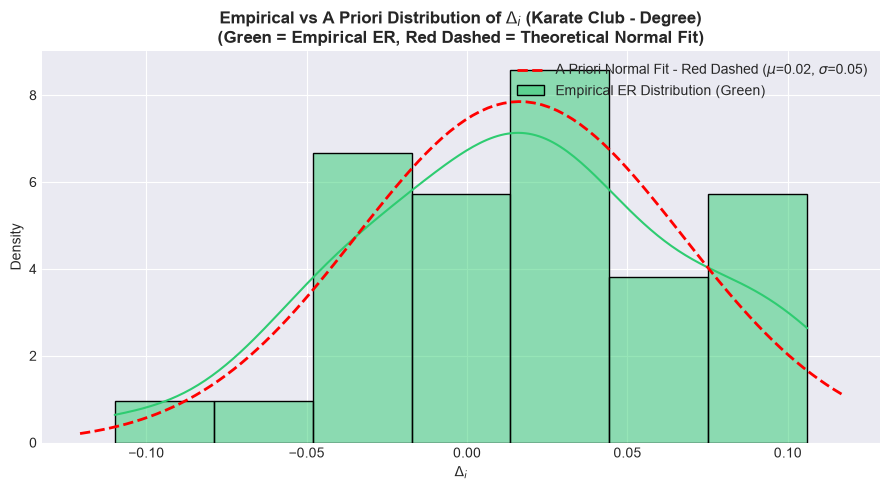

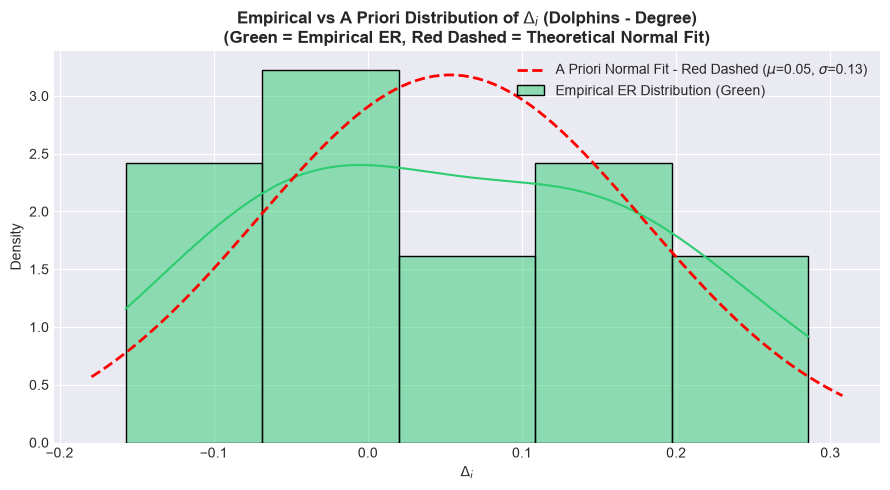

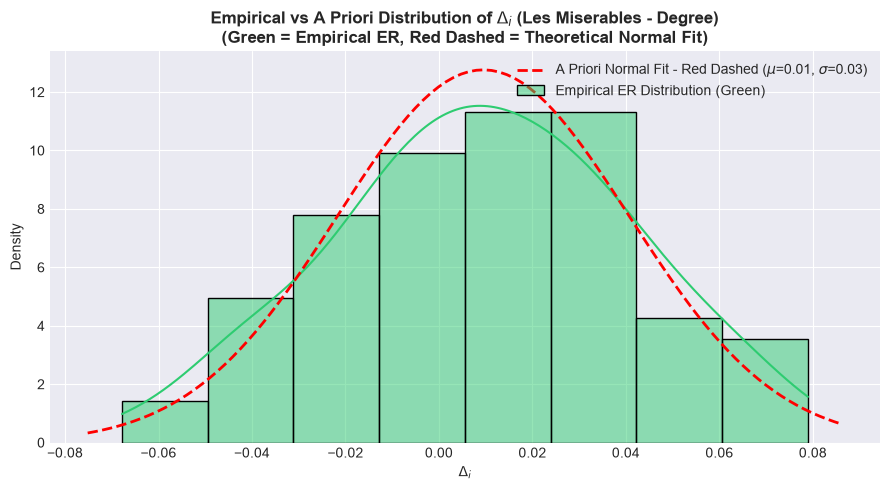

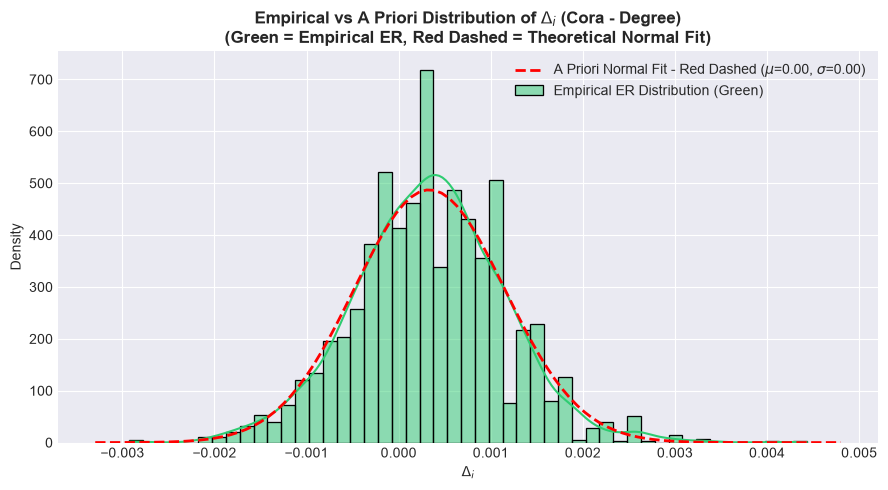

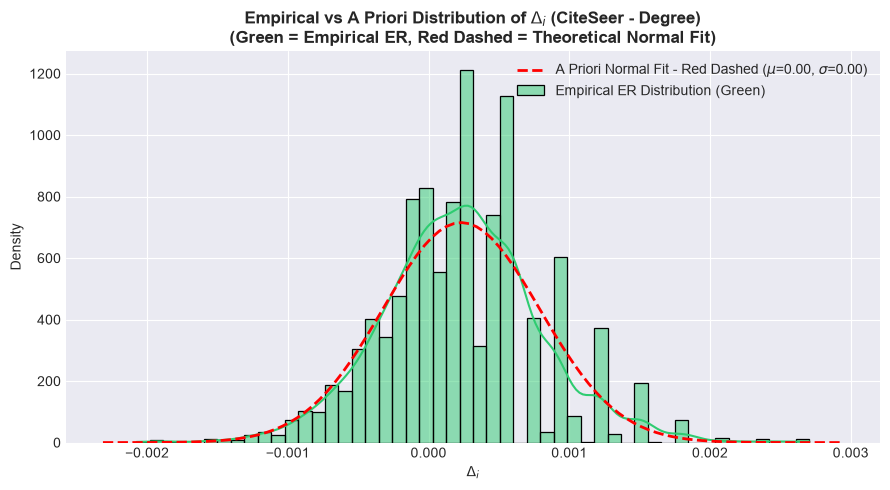

In [30]:
#PLOT 2: Empirical vs A Priori Normal Distribution of Delta_i
for target_graph in df_details["Graph"].unique():

  sample_delta_rand = df_details[
      (df_details["Graph"] == target_graph)
      & (df_details["Type"] == "Random (ER)")
      & (df_details["Centrality"] == "Degree")
  ]["Delta_i"].dropna()

  if sample_delta_rand.empty:
    continue

  plt.figure(figsize=(9, 5))

  sns.histplot(
      sample_delta_rand,
      kde=True,
      stat="density",
      color="#2ecc71",
      label="Empirical ER Distribution (Green)",
  )

  mu, std = norm.fit(sample_delta_rand)
  xmin, xmax = plt.xlim()
  x_axis = np.linspace(xmin, xmax, 100)
  p_theoretical = norm.pdf(x_axis, mu, std)

  plt.plot(
      x_axis,
      p_theoretical,
      "r--",
      linewidth=2,
      label=(
          f"A Priori Normal Fit - Red Dashed ($\mu$={mu:.2f},"
          f" $\sigma$={std:.2f})"
      ),
  )

  plt.title(
      f"Empirical vs A Priori Distribution of $\Delta_i$ ({target_graph} -"
      " Degree)\n(Green = Empirical ER, Red Dashed = Theoretical Normal Fit)",
      fontweight="bold",
  )
  plt.xlabel(r"$\Delta_i$")
  plt.ylabel("Density")
  plt.legend(loc="upper right")
  plt.tight_layout()

  filename_slug = target_graph.lower().replace(" ", "_")
  plt.savefig(
      f"figs/delta_empirical_vs_normal_{filename_slug}_degree.pdf",
      bbox_inches="tight",
  )
  plt.show()
  plt.close()

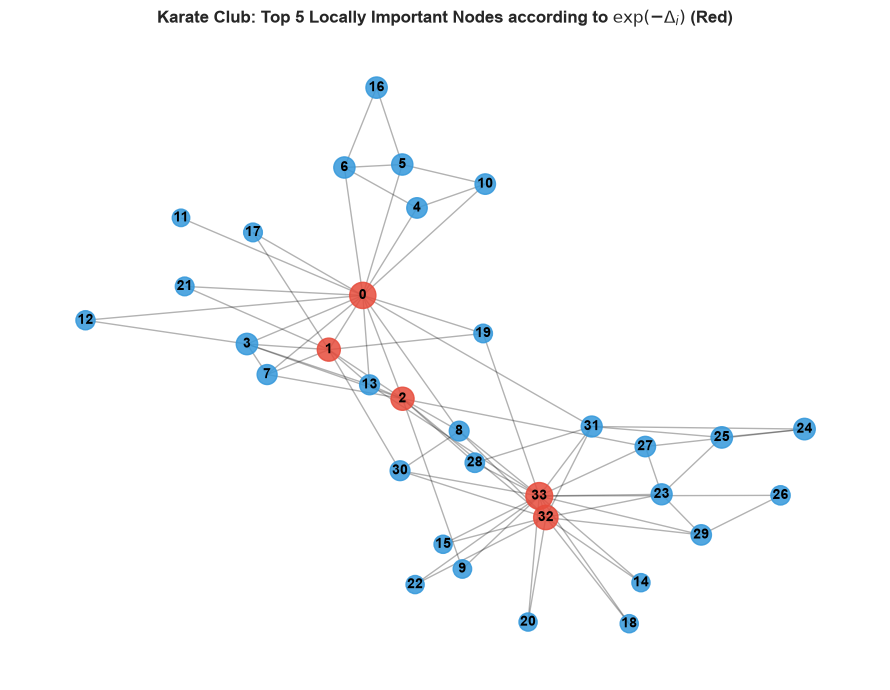

In [31]:
#PLOT 3: Visualization Top 5 Important Nodes with exp(-Delta_i)
G_demo = graphs['Karate Club']
delta_demo, imp_demo, _ = delta_values(G_demo, degree_centrality)

top5_nodes = sorted(imp_demo, key=imp_demo.get, reverse=True)[:5]
node_colors = [
    '#e74c3c' if n in top5_nodes else '#3498db' for n in G_demo.nodes()
]
node_sizes = [imp_demo[n] * 250 for n in G_demo.nodes()]

plt.figure(figsize=(9, 7))
pos = nx.spring_layout(G_demo, seed=42)
nx.draw_networkx_nodes(
    G_demo, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85
)
nx.draw_networkx_edges(G_demo, pos, alpha=0.3)
nx.draw_networkx_labels(G_demo, pos, font_size=10, font_weight='bold')

plt.title(
    r'Karate Club: Top 5 Locally Important Nodes according to $\exp(-\Delta_i)$'
    ' (Red)',
    fontweight='bold',
)
plt.axis('off')
plt.tight_layout()
plt.savefig(
    "figs/top5_important_nodes_exp_minus_delta_karate_club.pdf",
    bbox_inches="tight"
)
plt.show()